# Preparation of a FEMTIC inversion input files: data and mesh 

Example with the AusLAMP South Australia Dataset

In [57]:
import sys
sys.path.append('../femticPy/src/')
import femticPy
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare inversion data file

In [58]:
# the file will be written in the input_data directory
inversion = femticPy.DataGen(survey = 'Valles_FEMTIC', outdir = './input_data/inv')

In [59]:
# Loading the data and the data coordinates
inversion.read_MTdata('./input_data/edi_files/')
inversion.read_MTdata_coordinates('./input_data/geometry', 'sites_coord_elev.dat')

    reading EIS01003.edi
    reading EIS01004.edi
    reading EIS01005.edi
    reading EIS01006.edi
    reading EIS01007.edi
    reading EIS01008.edi
    reading EIS01009.edi
    reading EIS01010.edi
    reading EIS01011.edi
    reading EIS01012.edi
    reading EIS02003.edi
    reading EIS02004.edi
    reading EIS02005.edi
    reading EIS02006.edi
    reading EIS02007.edi
    reading EIS02008.edi
    reading EIS02009.edi
    reading EIS02010.edi
    reading EIS02011.edi
    reading EIS02012.edi
    reading EIS03003.edi
    reading EIS03004.edi
    reading EIS03005.edi
    reading EIS03006.edi
    reading EIS03008.edi
    reading EIS03009.edi
    reading EIS03010.edi
    reading EIS03011.edi
    reading EIS03012.edi
    reading EIS04003.edi
    reading EIS04004.edi
    reading EIS04005.edi
    reading EIS04006.edi
    reading EIS04007.edi
    reading EIS04008.edi
    reading EIS04009.edi
    reading EIS04010.edi
    reading EIS04011.edi
    reading EIS04012.edi
    reading EIS05003.edi


In [60]:
## Data to be inverted for
inversion.invert_Z   = True
inversion.invert_VTF = False
inversion.invert_PT  = False

In [61]:
# load the 3 files needed to create the mesh
inversion.topography = './input_data/geometry/topography_for.dat'
inversion.bathymetry = './input_data/geometry/bathymetry_for.dat'
inversion.coast_line = './input_data/geometry/coast_line.dat'

# Setting the Center of the model

In [62]:
# we center the data to a anchor point (center of the data set) which will also be the center of the future mesh
# inversion.center_data()
# inversion.anchor

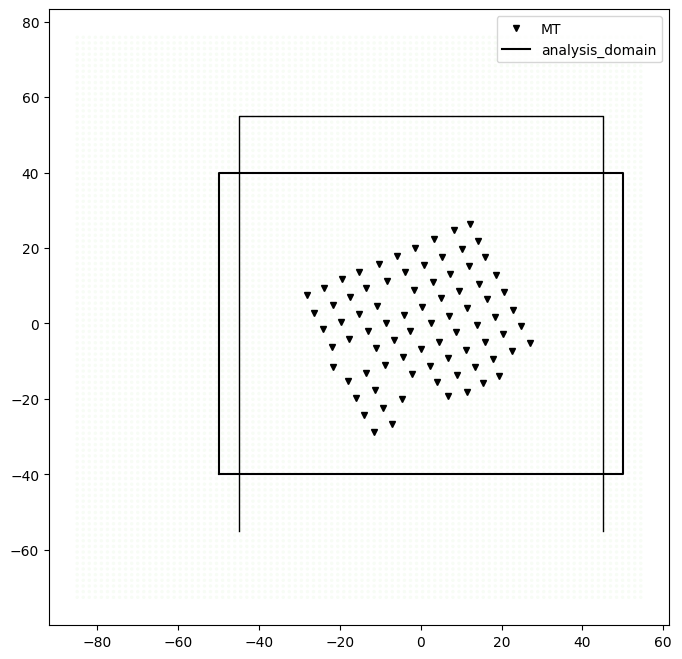

In [63]:
# we define the analysis domain, the extent of the total mesh including padding
inversion.analysis_domain = [[-50.0, 50.0],
                                [-40.0, 40.0],
                                [-50.0, 50.0]]
inversion.plot_data_loc(plot_ids = False, zoom_core=False)
inversion.plot_coast_line()
inversion.plot_topo_bathy()

# Aqui intento visualizar mejor el mapa 

In [64]:
#Despues de intentar mejorar el plot de la zona de estudio, continuo con el notebook original
inversion.mt_coords

,id,east,north,z
0,EIS01003,-28.02916,7.61968,-0.475
1,EIS01004,-24.00800,9.52872,-0.475
2,EIS01005,-19.39659,11.83023,-0.475
3,EIS01006,-15.24401,13.71013,-0.475
4,EIS01007,-10.41614,15.85993,-0.475
...,...,...,...,...
77,EIS09004,-7.13159,-26.70412,-0.475
78,EIS09007,6.71545,-19.25220,-0.475
79,EIS09008,11.56946,-18.25345,-0.475
80,EIS09009,15.50951,-15.83664,-0.475


In [65]:
# Set up error floors
# x% of (srqt(Zxy^2 + Zyx^2))
inversion.error_floor_Z = [0.2, 0.05, 0.05, 0.2]  # [Zxx, Zxy, Zyx, Zyy]

In [66]:
subsampling = 4
inversion.freqs[::subsampling]

array([1.e+03, 1.e+01, 1.e-01, 1.e-03])

Inversion data summary: 

  Inverting for 4 frequencies


  Impedance Z: 

  82 MT sites

  2624 Impedance tensor data points (full Z tensor, Real and Imag data) 

  Data points per frequencies: 

    T = 1.000E+03s  nData =  82 

    T = 1.000E+01s  nData =  82 

    T = 1.000E-01s  nData =  82 

    T = 1.000E-03s  nData =  82 



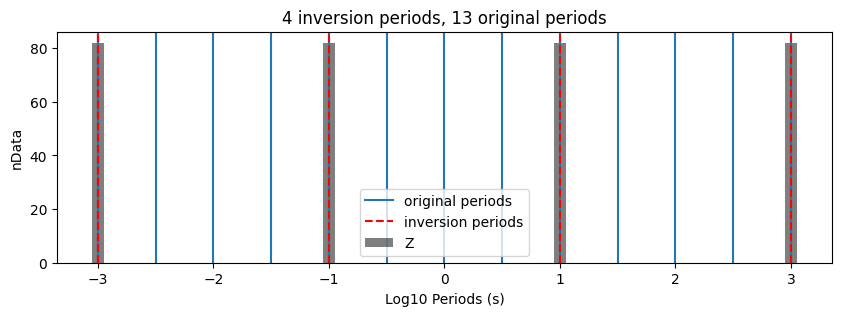

In [67]:
inversion.write_observe(write = True, freq_bandwidth = [0.001,1000], subsampling = subsampling)

# Plot data tensor

In [68]:
# Inspect the data before inversion
import MTtools as MTtools
MTtools.plot_Z(inversion)

Plotting observed data ...
   ...MT site  EIS01003
   ...MT site  EIS01004
   ...MT site  EIS01005
   ...MT site  EIS01006
   ...MT site  EIS01007
   ...MT site  EIS01008
   ...MT site  EIS01009
   ...MT site  EIS01010
   ...MT site  EIS01011
   ...MT site  EIS01012
   ...MT site  EIS02003
   ...MT site  EIS02004
   ...MT site  EIS02005
   ...MT site  EIS02006
   ...MT site  EIS02007
   ...MT site  EIS02008
   ...MT site  EIS02009
   ...MT site  EIS02010
   ...MT site  EIS02011
   ...MT site  EIS02012
   ...MT site  EIS03003
   ...MT site  EIS03004
   ...MT site  EIS03005
   ...MT site  EIS03006
   ...MT site  EIS03008
   ...MT site  EIS03009
   ...MT site  EIS03010
   ...MT site  EIS03011
   ...MT site  EIS03012
   ...MT site  EIS04003
   ...MT site  EIS04004
   ...MT site  EIS04005
   ...MT site  EIS04006
   ...MT site  EIS04007
   ...MT site  EIS04008
   ...MT site  EIS04009
   ...MT site  EIS04010
   ...MT site  EIS04011
   ...MT site  EIS04012
   ...MT site  EIS05003
   ...MT site

# -----------------------------------------------------------------------

# = = = = = = = = =  = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = 

# = = = = = = = = =  = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = 

# = = = = = = = = =  = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = 

<!-- # 2. Prepare inversion control file -->

In [14]:
# # Define inversion parameters:

# #TRADE_OFF_PARAM
# TRADE_OFF_PARAM = [3]

# # Max number of iterations
# ITERATION = 3

# # NUM_THREADS
# NUM_THREADS = 8

# # CONVERGE
# CONVERGE = 0.2

# # output directory
# outdir = './results'

In [15]:
# inversion.write_inversion_control(TRADE_OFF_PARAM = TRADE_OFF_PARAM,
#                                     ITERATION = ITERATION,
#                                     NUM_THREADS = NUM_THREADS,
#                                     CONVERGE = CONVERGE)

# Fin de preprocesado de inversion

# = = = = = = = = =  = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = 

# = = = = = = = = =  = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = 

# = = = = = = = = =  = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = 

# = = = = = = = = =  = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = 

# 3. Prepare mesh files

In [23]:
# output directory
outdir = 'iput_data/geometry'

In [24]:
# create meshGen object
mesh01 = femticPy.MeshGen(inversion.survey,
                          inversion.analysis_domain,
                          inversion.center,
                          inversion.mt_coords,
                          inversion.nRx_Z,
                         outdir)

In [25]:
mesh01.sea = False
mesh01.sea

False

In [26]:
# Step 1: 

# Define the mesh disretization, sphere centered on the mesh center 
    # core area: 650km sphere radius (isotropic) / max cell size : 50km (anisotropic in z)
    # padding: 2000km sphere radius (isotropic), max cell size: 500km (isotropic)

mesh01.center = [0.0, 0.0, 0.0]
mesh01.rotation = 0


# [N,
# [a, len, fh, fv+, fv-],
# [a, len, fh, fv+, fv-]]
mesh01.ellipsoids_control = [1,
                     [7.0, 5.0, 0.35, 0.95, 0.1]
                     ]

mesh01.coast_line = './input_data/coast_line_for.dat'

# mesh01.ellipsoids_observing_sites =  [6, 1.0, 0.5, 5.0, 1.0, 50.0, 15.0, 100.0, 25.0, 150.0,50.0, 200.0, 100.0]

# Hasta aqui se completan los step del 1 al 4

In [27]:
# Step 6: Refine
# this step refines the tetras around the MT sites

mesh01.ellipsoids_obs_sites = [4,
                    [1.0, 0.5, 0.0] ,          
                    [10.0, 5.0, 0.0] ,           
                    [100.0, 25.0, 0.0],         
                    [200.0, 100.0, 0.0],]


mesh01.ellipsoids_mtr = [2,
                    [400.0, 50.0, 0.0, 0.1, 0.1],
                    [2000.0, 500.0, 0.0, 0.0, 0.0]]

In [28]:
# Step 7: Write mesh to FEMTIC format
# the attr file will determine how tetras (elements) will be combined into cells (model parameters)

mesh01.ellipsoids_resistivity_attr = [3,
                    [4.0,       50.0,  0.0,  0.0],
                    [20.0,  500.0,  0.0,  0.0] ]
                     


mesh01.ellipsoids_resistivity_attr_sites = [3,                        
                    [10.0, 2.0],
                    [50.0, 10.0],
                    [150.0, 25.0]]

In [29]:
# Define the starting model resistivities (in ohm.m)
mesh01.resistivity_starting_model = 100

In [30]:
mesh01.write_inputs()

In [31]:
# number of regions (air, land, sea) 
mesh01.region_attributes

2

# 4. Run `create_mesh.sh`

the `create_mesh.sh` script call the `meshGen.sh` pipeline, that sequentially runs all the steps required to create the mesh. Depending on the size of the mesh this can take long (~ 10 min). 

"Step 4" in `meshGen.sh` needs to be modified to your problem:

```
#-----------------------"
#-----   STEP 4    -----"
#-----------------------"

echo "STEP 4... "
/scratch3/sei029/femtic/makeTetraMesh -stp 4
sed -i "$(( $(wc -l < output.poly) ))s/.*/3/" output.poly
echo "1   0.0 0.0 -40.0  10 1e9" >> output.poly
echo "2  -500.0 -500.0  1.0  20 1e9" >> output.poly
echo "3   0.0 0.0  40.0  30 1e9" >> output.poly
echo "   done!"
sleep 1
```

In this step, 3 lines are added to the `output.poly` file. They correspond to:

`"region_attribute   x   y   z   region_number   1e9"`

x, y, z (in km) should indicate at which location a sample of each region can be found. z is positive downwards.

The region numbers have to match with the ones in `resistivity_attr.dat`

```
3
10 1.0e+9 -1 1
20 0.250  -1 1
30 100.0   9 0
```

10 is for air, 20 for sea and 30 for earth (with associated resistivities)

"Step 5" in `meshGen.sh` calls a python script that fixes a bug that has been appearing sometimes. This is a temporary fix while understanding why a new region number (31 or 32) sometimes appears during step 5. 

```
echo "fix output.1.ele if necessary... "
module load python
python fix_output1.py
sleep 1
echo "   done!"
```

To check the size of the mesh, check the `resistivity_block_iter0.dat` file. The first number is the number of elements, the second is te number of cells.

```
>head resistivity_block_iter0.dat 
   1453333    206736
         0         0
....
```

# 5. Visualise the mesh using paraview (before running the inversion)

Setting up the ellipsoids is cumbersome and takes some trials to obtain a mesh that looks ok, in terms of cells discretization and mesh size. 

If the shell script has run properly, the final files to be used for the inversion should be:
- resistivity_block_iter0.dat
- mesh.dat



The output files that can be copied over and are useful for visualization are:

- output.6.femtic.vtk
   - to check the model parameter discretization (the cells), use the blockSerial attribute of the .vtk file
- triangles_with_height.vtk
- coastLine_fine.vtk
- coastLine_rough.vtk

The last 3 files are in km, and a transform filter has to be applied in paraview to be visualized with `output.6.femtic.vtk` (which is m)

# 6. Running the inversion using `run_inversion.sh`